In [2]:
import torch
import torch.nn as nn
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [17]:
import matplotlib.pyplot as plt

In [8]:
from tqdm import tqdm
from pinn.model import pinn
import pinn.utils as utils
import pinn.dataset as ds

In [ ]:
K = 100
r = 0.5
pini = 50
t = torch.linspace(0, 10, 100).to(device).reshape(-1, 1)
psol = K* torch.exp(r* t) / (1+ torch.exp(r *t))

In [10]:
num_hidden = 2
num_nodes = 8

layer_list = [1] + num_hidden*[num_nodes] + [1]
model = pinn(layer_list).to(device)

In [11]:
lr = 1e-2
epochs = 5000
optimizer = optim.Adam(model.parameters(), lr=lr)

In [12]:
loss_graph = []
t_req = t.clone()
t_req.requires_grad = True

for epoch in tqdm(range(epochs)):
    optimizer.zero_grad()
    p0_pred = model(t[0:1])
    p_pred = model(t_req)

    loss_col = torch.mean(utils.population_growth(p_pred, t_req)**2)
    loss_max = torch.max(utils.population_growth(p_pred, t_req)**2) # 잔차로만 loss를 줄이면 trivial solution이 나올 수 있어서 방지를 위해 추가함
    loss_init = torch.mean((p0_pred-pini)**2) # mse loss
    loss = loss_col + loss_init + loss_max 

    loss.backward()

    optimizer.step()

    loss_graph.append(loss.item())

print(f"mse: {loss_graph[-1]}")
print(f"p0: {p0_pred.item()}")
torch.save(model.state_dict(), './params/ppl.pt')

  0%|          | 0/5000 [00:00<?, ?it/s]c:\Coding\mnist_cnn\.venv\Lib\site-packages\torch\autograd\graph.py:865: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\cuda\CublasHandlePool.cpp:330.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass
100%|██████████| 5000/5000 [01:06<00:00, 74.67it/s]

mse: 0.001390969380736351
p0: 50.00250244140625


In [16]:
model.load_state_dict(torch.load('./params/ppl.pt', map_location=device))

with torch.no_grad():
    p_pred = model(t)

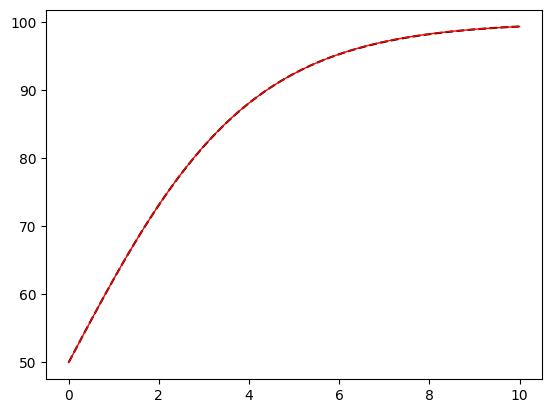

In [ ]:
plt.plot(t.cpu().numpy(), psol.cpu().numpy(), '--', color='black')
plt.plot(t.cpu().numpy(), p_pred.cpu().numpy(), color='red', linewidth=1)
plt.show()

# 빨간색이 모델의 예측